## Seminar II: Numpy
March 4, 2026
_______________________

In [ ]:
# install requirements if needed

# !pip install numpy matplotlib pandas

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Exercise 1 — Simulate a 1D array of simulated daily temperatures
* Use normal distribution with `mean = 15` and `sd = 5`
* Simulate 28 days of daily temperatures
* Save as temps object
* Convert the from Celsius to Fahrenheit and save as temps_fahrenheit
$$fahrenheit = 1.8 * celsius + 32$$

In [8]:
temps = np.random.normal(15, 5, 28)
temps_fahrenheit = 1.8 * temps + 32

#### Print shape and dtype of temps

In [9]:
print(temps.shape, temps.dtype)

(28,) float64


#### Reshape temps so that it consists of 4 rows (weeks) and 7 columns (days of week)

In [15]:
temps = temps.reshape(4, 7)

####  Use slicing to display
* all Wednesday values (assume week starting on Monday) 
* Week #2
* 1st and 3rd week

* verify that all temperatures are higher than 5 degrees Celsius
* verify that all temperatures are lower than 30 degrees Celsius

In [16]:
temps

array([[24.14352172, 27.22190383,  8.23896231,  9.09152612, 11.95005007,
        16.13185899, 14.06809295],
       [15.06363423, 12.02075261, 13.47219795, 11.99039779, 11.49756221,
        10.64017689, 10.38935873],
       [17.32597918, 14.34371929, 13.14180557, 15.40721166, 14.74720122,
        15.23517417, 19.17842778],
       [14.75412365,  9.59697451, 11.65677487, 20.96169766, 16.14267972,
        23.3319188 , 16.51331535]])

In [17]:
temps[:, 2]

array([ 8.23896231, 13.47219795, 13.14180557, 11.65677487])

In [ ]:
temps[[1,3],:]
temps[1::2,:]

array([[15.06363423, 12.02075261, 13.47219795, 11.99039779, 11.49756221,
        10.64017689, 10.38935873],
       [14.75412365,  9.59697451, 11.65677487, 20.96169766, 16.14267972,
        23.3319188 , 16.51331535]])

In [24]:
(temps > 5).all()

np.True_

In [ ]:
(temps < 30).all()

#### Print mean temperatures 
* Overall in Celsius and Fahrenheit
* For each day in Celsius
* For each week in Celsius

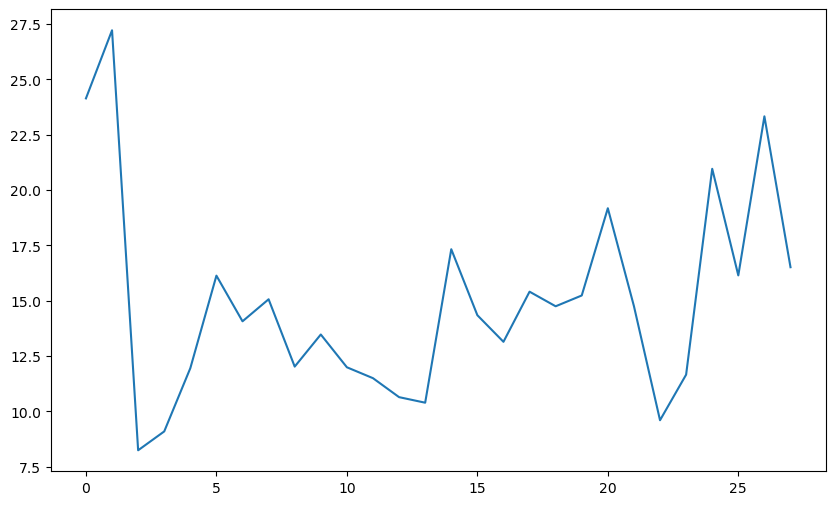

In [29]:
plt.figure(figsize = (10,6))
plt.plot(temps.flatten(), label='Celsius')



#### Plot both temperature series into 1 plot

### Exercise 2 - Simulate 2D array of artificial stock returns
* Simulate 1 year of data (252 observations) and 5 stocks
* Simulate from normal distribution with the defined means and standard deviations
* Compute sample mean and standard deviation for each of the assets

In [56]:
np.random.seed(523)
means = np.array([0, -0.001, 0, 0.005, .001])
sds = np.array([0.04, 0.07, 0.07, 0.02, 0.1])
initial_prices = np.array([28, 123, 45, 320, 213])



In [57]:
returns = np.random.normal(means, sds, size=(252,5))
returns

array([[ 0.03619701, -0.01668216,  0.04168031,  0.00527968, -0.05439768],
       [-0.02312977,  0.01330126, -0.13944184,  0.03715006,  0.18650869],
       [ 0.03430771, -0.05809472, -0.06289887,  0.01344342,  0.01486039],
       ...,
       [ 0.05062979,  0.00769596, -0.08072852,  0.02316717,  0.05337034],
       [ 0.00269719, -0.06904073, -0.04058455, -0.02144647, -0.04880861],
       [ 0.01446492, -0.0758512 ,  0.0494782 , -0.00168821,  0.05859699]],
      shape=(252, 5))

In [58]:
initial_prices


array([ 28, 123,  45, 320, 213])

#### Use initial prices and your returns to reconstruct prices
* Then compute log-returns of the series

In [59]:
prices = np.append(initial_prices, 1 + returns).reshape(-1, 5)
prices = np.cumprod(prices, axis = 0)
prices

array([[ 28.        , 123.        ,  45.        , 320.        ,
        213.        ],
       [ 29.01351625, 120.94809492,  46.87561408, 321.68949622,
        201.41329473],
       [ 28.34244037, 122.55685717,  40.33919215, 333.64027903,
        238.9786247 ],
       ...,
       [ 23.16603561,  13.55523559,   5.7692467 , 703.05051782,
        430.86897435],
       [ 23.22851873,  12.61937223,   5.53510441, 687.972563  ,
        409.83885894],
       [ 23.56451744,  11.6621777 ,   5.80897139, 686.81112093,
        433.85418352]], shape=(253, 5))

In [60]:
returns = np.diff(np.log(prices), axis = 0)
returns

array([[ 0.03555729, -0.01682287,  0.04083509,  0.00526579, -0.05593318],
       [-0.02340146,  0.01321358, -0.15017408,  0.03647662,  0.17101512],
       [ 0.03373233, -0.05985056, -0.06496407,  0.01335386,  0.01475106],
       ...,
       [ 0.04938978,  0.00766649, -0.08417379,  0.02290288,  0.05199488],
       [ 0.00269356, -0.07153975, -0.04143109, -0.02167979, -0.05003998],
       [ 0.0143613 , -0.07888218,  0.04829308, -0.00168964,  0.05694444]],
      shape=(252, 5))

#### Compute the correlation for each of the asset pairs

In [62]:
print(np.corrcoef(returns.T))

[[ 1.00000000e+00  1.39630337e-05  1.57720606e-02  3.47384961e-02
  -1.86899916e-02]
 [ 1.39630337e-05  1.00000000e+00  2.33826590e-02  4.07030688e-02
   7.79610211e-02]
 [ 1.57720606e-02  2.33826590e-02  1.00000000e+00  1.80599035e-02
  -1.46826561e-03]
 [ 3.47384961e-02  4.07030688e-02  1.80599035e-02  1.00000000e+00
   7.75060702e-02]
 [-1.86899916e-02  7.79610211e-02 -1.46826561e-03  7.75060702e-02
   1.00000000e+00]]


#### Extract
* returns of the 2nd asset for Wednesdays (assume each week has 5 days and the sample starts Monday)
* all returns of stocks 1 and 4

#### Identify days where average return across assets is greater than 0

In [64]:
(returns.mean(axis=1)>0).sum()

np.int64(126)

#### Plot the returns
* Plot the time series of raw returns
* Assume that you make an initial investment of 1 USD. Compute and plot the evolution of such investment for each asset.

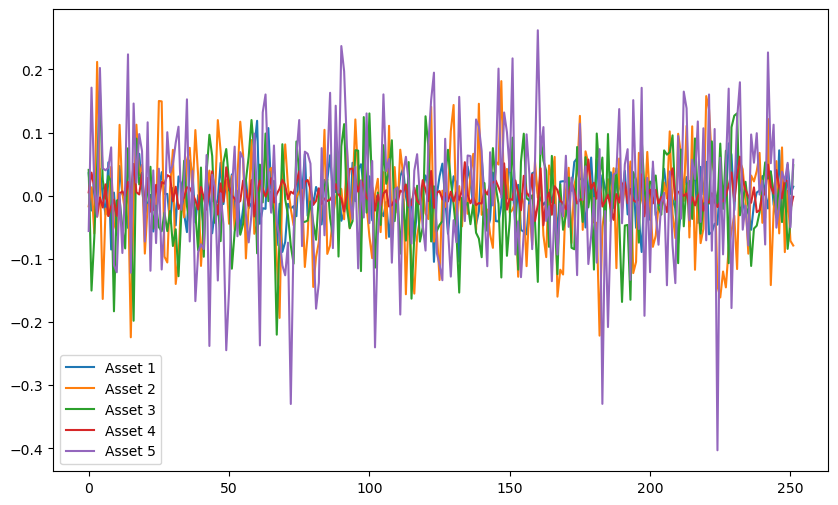

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(returns)
plt.legend([f"Asset {i+1}" for i in range(5)])

#### Plot histogram of returns for asset 2

---
### Exercise 3 — 3D array (image)

First we will load the image into a 3D array

In [ ]:

img = plt.imread("03_pics/mc_escher_print gallery.png")
plt.imshow(img, interpolation="nearest", aspect="auto")
plt.axis('off')

In [ ]:
# Verify that all the values are lower than 1


#### Remove each of the primary colors
* Create a copy of img and save it as img2
* Set all the values for `Red` to 0 and display the image
* Set all the values for `Green` to 0 and display the image
* Set all the values for `Blue` to 0 and display the image

In [ ]:
# remove red


In [ ]:
# remove green


In [ ]:
# remove blue


#### Invert the grayscale of the image
* What was white should be black, etc.

In [ ]:
inverted = img.copy()


#### Add Gaussian noise to the picture
* Create an np.array from normal distribution with `mean = 0` and `sd = 0.1` of shape (1024, 1280, 3), and add it to the RGB colors
* employ clipping of the values to the interval `[0, 1]`

In [ ]:
noisy = img.copy()


#### Flip the image horizontally

* You can use np.flip()
* Keep the `A` values

#### Flatten the image and then reconstruct it

#### Bonus: create a checkerboard mask to selectively white every other 8×8 block.

In [ ]:
h, w, _ = img.shape
block = 8 

# Compute how many 8×8 blocks fit in each dimension
h_blocks = h // block
w_blocks = w // block

# Create a checkerboard pattern using addition mod 2
checker = (np.add.outer(np.arange(h_blocks), np.arange(w_blocks)) % 2).astype(bool)
mask = np.kron(checker, np.ones((block, block), dtype=bool))

# Apply mask: zero every other block
checker_img = img.copy()
checker_img[~mask] = 1  # zero RGBA pixels in the masked-out blocks

plt.imshow(checker_img)
plt.title("Checkerboard Mask (8×8 Blocks)")
plt.axis("off")
plt.show()